# Sử dụng kỹ thuật `CNN + LSTM`

In [1]:
# Cell 1 — Imports & helper functions
import pandas as pd
import numpy as np
from pathlib import Path

DATA_HYDRO = Path("./data_thuydien/du_lieu_thuy_dien_processed_final2.csv")
DATA_WEATHER = Path("./data_thuydien/HoaBinh.csv")

def smart_read_csv(path):
    """Try common encodings to read CSV robustly."""
    for enc in ["utf-8", "utf-8-sig", "cp1258", "latin-1", "utf-16"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    raise last_err

def find_col(df, candidates):
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    # fuzzy contains
    for c in cols:
        lc = c.lower()
        if any(cand in lc for cand in candidates):
            return c
    return None

def to_datetime_col(df, colname, dayfirst=True):
    df[colname] = pd.to_datetime(df[colname], errors="coerce", dayfirst=dayfirst, utc=False)
    # Drop rows that failed to parse
    before = len(df)
    df = df.dropna(subset=[colname]).copy()
    after = len(df)
    if after < before:
        print(f"[INFO] Dropped {before-after} rows due to invalid datetimes in '{colname}'.")
    # Normalize to hourly alignment to improve join rate
    df[colname] = df[colname].dt.floor("H")
    return df

print("✓ Helpers ready.")


✓ Helpers ready.


In [2]:
# Cell 2 — Load raw data & inspect columns
hydro_raw = smart_read_csv(DATA_HYDRO)
weather_raw = smart_read_csv(DATA_WEATHER)

print("[Hydro] shape:", hydro_raw.shape)
print(hydro_raw.columns.tolist()[:50])

print("\n[Weather] shape:", weather_raw.shape)
print(weather_raw.columns.tolist()[:50])


[Hydro] shape: (33264, 22)
['thoi_diem', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s_capped', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s', 'phase_pre_lu_som', 'phase_lu_som', 'phase_lu_chinh_vu', 'phase_tai_tich', 'pct_change', 'anom_iqr_units', 'out_pct', 'is_event_month', 'luu_luong_den_ho_m3_s_capped_month_median', 'luu_luong_den_ho_m3_s_capped_pct_in_month', 'max_xa_dap_tran', 'max_xa_nha_may', 'dap_tran_norm', 'nha_may_norm', 'month', 'mua_vu']

[Weather] shape: (33264, 10)
['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'wind_speed_10m (km/h)', 'cloud_cover (%)', 'surface_pressure (hPa)', 'et0_fao_evapotranspiration (mm)', 'rain (mm)', 'snowfall (cm)']


In [3]:
# Cell 3 (làm lại) — Chuẩn hoá time (M/D/YYYY HH:MM), sort theo thoi_diem (datetime), và merge không mất dòng
import pandas as pd
from pathlib import Path

HYDRO_CSV   = Path("./data_thuydien/du_lieu_thuy_dien_processed_final2.csv")
WEATHER_CSV = Path("./data_thuydien/HoaBinh.csv")
OUT_MERGED  = Path("./data_thuydien/merged_hoa_binh_keyjoin.csv")

TIME_COL_HYDRO   = "thoi_diem"
TIME_COL_WEATHER = "time"

WEATHER_KEEP = ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'cloud_cover (%)']
WEATHER_RENAME = {
    'temperature_2m (°C)': 'temp_c',
    'relative_humidity_2m (%)': 'rh_pct',
    'precipitation (mm)': 'precip_mm',
    'cloud_cover (%)': 'cloud_pct'
}

DROP_COLS = ['month', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s',
             'tong_luong_xa_qua_nha_may_m3_s', 'max_xa_dap_tran', 'max_xa_nha_may']

def smart_read_csv(path):
    for enc in ["utf-8", "utf-8-sig", "cp1258", "latin-1", "utf-16"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return pd.read_csv(path)

def parse_best_datetime(series):
    s1 = pd.to_datetime(series, errors="coerce", dayfirst=False)
    s2 = pd.to_datetime(series, errors="coerce", dayfirst=True)
    if s1.notna().sum() >= s2.notna().sum():
        return s1
    return s2

def to_key_string(dt_series):
    dt = pd.to_datetime(dt_series, errors="coerce").dt.floor("H")
    return (dt.dt.month.astype("Int64").astype(str) + "/" +
            dt.dt.day.astype("Int64").astype(str) + "/" +
            dt.dt.year.astype("Int64").astype(str) + " " +
            dt.dt.hour.astype("Int64").astype(str).str.zfill(2) + ":" +
            dt.dt.minute.astype("Int64").astype(str).str.zfill(2))

# 1) Read
hydro_raw   = smart_read_csv(HYDRO_CSV)
weather_raw = smart_read_csv(WEATHER_CSV)

# 2) Weather: chọn cột, parse & tạo key
weather = weather_raw[[TIME_COL_WEATHER] + WEATHER_KEEP].copy()
weather["__dt_w"] = parse_best_datetime(weather[TIME_COL_WEATHER]).dt.floor("H")
weather = weather.dropna(subset=["__dt_w"]).copy()
weather["time_key"] = to_key_string(weather["__dt_w"])
weather = weather.rename(columns=WEATHER_RENAME)

# 3) Hydro: drop cột thừa, parse & tạo key
hydro = hydro_raw.drop(columns=[c for c in DROP_COLS if c in hydro_raw.columns], errors="ignore").copy()
assert TIME_COL_HYDRO in hydro.columns, f"Thiếu cột {TIME_COL_HYDRO} trong thủy điện"
hydro["__dt_h"] = parse_best_datetime(hydro[TIME_COL_HYDRO]).dt.floor("H")
hydro = hydro.dropna(subset=["__dt_h"]).copy()
hydro["time_key"] = to_key_string(hydro["__dt_h"])

# 4) Xử lý trùng time_key trước khi merge (giữ bản ghi đầu tiên mỗi time_key)
hydro = hydro.sort_values("__dt_h").drop_duplicates(subset=["time_key"], keep="first")
weather = weather.sort_values("__dt_w").drop_duplicates(subset=["time_key"], keep="first")

# 5) Merge và tạo lại thoi_diem chuẩn datetime
merged = pd.merge(
    hydro.drop(columns=["__dt_h"]), 
    weather.drop(columns=["__dt_w"]),
    on="time_key", how="inner", suffixes=("", "_w")
)

# Dự phòng: nếu cột 'thoi_diem' là chuỗi, tạo lại từ time_key để đảm bảo chuẩn
merged["thoi_diem"] = pd.to_datetime(merged["thoi_diem"], errors="coerce")
mask_na = merged["thoi_diem"].isna()
if mask_na.any():
    merged.loc[mask_na, "thoi_diem"] = pd.to_datetime(merged.loc[mask_na, "time_key"], format="%m/%d/%Y %H:%M", errors="coerce")

# 6) Sort theo thoi_diem và reset index
merged = merged.sort_values("thoi_diem").reset_index(drop=True)

# 7) Kiểm tra độ bao phủ thời gian
print("Merged shape:", merged.shape)
print("Time range:", merged["thoi_diem"].min(), "->", merged["thoi_diem"].max())
print("Head times:", merged["thoi_diem"].head().tolist())
print("Tail times:", merged["thoi_diem"].tail().tolist())

# 8) Lưu
merged.to_csv(OUT_MERGED, index=False)
print("Saved merged sorted to:", OUT_MERGED)


Merged shape: (33264, 22)
Time range: 2022-01-01 00:00:00 -> 2025-10-17 23:00:00
Head times: [Timestamp('2022-01-01 00:00:00'), Timestamp('2022-01-01 01:00:00'), Timestamp('2022-01-01 02:00:00'), Timestamp('2022-01-01 03:00:00'), Timestamp('2022-01-01 04:00:00')]
Tail times: [Timestamp('2025-10-17 19:00:00'), Timestamp('2025-10-17 20:00:00'), Timestamp('2025-10-17 21:00:00'), Timestamp('2025-10-17 22:00:00'), Timestamp('2025-10-17 23:00:00')]
Saved merged sorted to: data_thuydien/merged_hoa_binh_keyjoin.csv


In [4]:
import pandas as pd
from pathlib import Path

MERGED_PATH = Path('./data_thuydien/merged_hoa_binh_keyjoin.csv')
TARGET_COL = 'muc_nuoc_thuong_luu_m'
FEATURE_WEATHER = ['temp_c','rh_pct','precip_mm','cloud_pct']

df = pd.read_csv(MERGED_PATH)
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce', dayfirst=False)
df = df.sort_values('thoi_diem').reset_index(drop=True)

n = len(df)
split_idx = int(n*0.8)
df_train = df.iloc[:split_idx].reset_index(drop=True)
df_test  = df.iloc[split_idx:].reset_index(drop=True)

print('Train:', df_train['thoi_diem'].min(), '->', df_train['thoi_diem'].max(), len(df_train))
print('Test :', df_test['thoi_diem'].min(),  '->', df_test['thoi_diem'].max(),  len(df_test))


Train: 2022-01-01 00:00:00 -> 2025-01-13 18:00:00 26611
Test : 2025-01-13 19:00:00 -> 2025-10-17 23:00:00 6653


In [5]:
# Cell 5 — Sequences 2 kênh (mực nước + lưu lượng) với lookback = 30d và downsample theo STRIDE
import numpy as np

# ===== Cấu hình =====
LOOKBACK_DAYS = 28      # đổi 7 nếu muốn 1 tuần
STRIDE = 2              # lấy mỗi 2 mốc thời gian -> giảm L ~ một nửa. Đặt =1 nếu muốn full
FEATURE_WEATHER = ['temp_c','rh_pct','precip_mm','cloud_pct']
TARGET_COL = 'muc_nuoc_thuong_luu_m'
INFLOW_CANDIDATES = ['luu_luong_den_ho_m3_s_capped', 'luu_luong_den_ho_m3_s']

# ===== Kiểm tra =====
INFLOW_COL = next((c for c in INFLOW_CANDIDATES if c in df.columns), None)
assert INFLOW_COL is not None, "Không tìm thấy cột lưu lượng đến hồ trong df merged."
assert 'split_idx' in globals(), "Chưa có split_idx (Cell 4)."

# ===== Suy ra bước thời gian (giờ) -> số bước mỗi ngày =====
delta_hours = df['thoi_diem'].diff().dt.total_seconds().dropna() / 3600.0
median_step_h = float(delta_hours.median()) if len(delta_hours)>0 else 1.0
steps_per_day = int(round(24.0 / median_step_h)) if median_step_h>0 else 24
LOOKBACK_STEPS = LOOKBACK_DAYS * steps_per_day
print(f"Median step (h)= {median_step_h:.2f} | steps/day= {steps_per_day} | RAW_LOOKBACK_STEPS= {LOOKBACK_STEPS}")

# ===== Chuẩn bị dữ liệu =====
need_cols = ['thoi_diem', TARGET_COL, INFLOW_COL] + FEATURE_WEATHER
sub = df[need_cols].dropna().reset_index(drop=True)

lvl = sub[TARGET_COL].values.astype('float32')    # mực nước
inf = sub[INFLOW_COL].values.astype('float32')    # lưu lượng
w   = sub[FEATURE_WEATHER].values.astype('float32')
y_all = sub[TARGET_COL].values.astype('float32')

# ===== Build sequences: X_seq (N, L_eff, 2), X_w (N, 4), y (N,) =====
X_seq, X_w, y, t_idx = [], [], [], []
for t in range(LOOKBACK_STEPS, len(sub)):
    win_lvl = lvl[t-LOOKBACK_STEPS:t]
    win_inf = inf[t-LOOKBACK_STEPS:t]
    # downsample theo STRIDE để giảm độ dài sequence
    win_lvl = win_lvl[::STRIDE]
    win_inf = win_inf[::STRIDE]
    seq_2ch = np.stack([win_lvl, win_inf], axis=1)  # (L_eff, 2)

    X_seq.append(seq_2ch.astype('float32'))
    X_w.append(w[t].astype('float32'))
    y.append(y_all[t].astype('float32'))
    t_idx.append(sub.index[t])

X_seq = np.stack(X_seq, axis=0)   # (N, L_eff, 2)
X_w   = np.stack(X_w,   axis=0)   # (N, 4)
y     = np.array(y, dtype='float32')
t_idx = np.array(t_idx)

# ===== Split theo split_idx =====
train_mask = t_idx < split_idx
test_mask  = t_idx >= split_idx

Xseq_tr, Xw_tr, y_tr = X_seq[train_mask], X_w[train_mask], y[train_mask]
Xseq_te, Xw_te, y_te = X_seq[test_mask],  X_w[test_mask],  y[test_mask]

SEQ_FEAT_DIM = Xseq_tr.shape[2]   # = 2
L_eff = Xseq_tr.shape[1]
print('Train/Test shapes:', Xseq_tr.shape, Xseq_te.shape, y_tr.shape, y_te.shape, '| SEQ_FEAT_DIM=', SEQ_FEAT_DIM, '| L_eff=', L_eff)


Median step (h)= 1.00 | steps/day= 24 | RAW_LOOKBACK_STEPS= 672
Train/Test shapes: (25939, 336, 2) (6653, 336, 2) (25939,) (6653,) | SEQ_FEAT_DIM= 2 | L_eff= 336


In [6]:
# Cell 6 — Scaling (đa kênh)
import numpy as np
from sklearn.preprocessing import StandardScaler

Ntr, L_eff, F = Xseq_tr.shape
Nte = Xseq_te.shape[0]

seq_scaler = StandardScaler()
w_scaler   = StandardScaler()
y_scaler   = StandardScaler()

# Flatten (N, L*F) rồi reshape lại (N, L, F)
Xseq_tr_2d = Xseq_tr.reshape(Ntr, L_eff*F)
Xseq_te_2d = Xseq_te.reshape(Nte, L_eff*F)

Xseq_tr_s = seq_scaler.fit_transform(Xseq_tr_2d).astype('float32').reshape(Ntr, L_eff, F)
Xseq_te_s = seq_scaler.transform(Xseq_te_2d).astype('float32').reshape(Nte, L_eff, F)

Xw_tr_s = w_scaler.fit_transform(Xw_tr).astype('float32')
Xw_te_s = w_scaler.transform(Xw_te).astype('float32')

y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1)).astype('float32').ravel()
y_te_s = y_scaler.transform(y_te.reshape(-1, 1)).astype('float32').ravel()

print("Scaled shapes OK:",
      "Xseq_tr_s:", Xseq_tr_s.shape, "| Xseq_te_s:", Xseq_te_s.shape,
      "| Xw_tr_s:", Xw_tr_s.shape, "| Xw_te_s:", Xw_te_s.shape,
      "| y_tr_s:", y_tr_s.shape, "| y_te_s:", y_te_s.shape)


Scaled shapes OK: Xseq_tr_s: (25939, 336, 2) | Xseq_te_s: (6653, 336, 2) | Xw_tr_s: (25939, 4) | Xw_te_s: (6653, 4) | y_tr_s: (25939,) | y_te_s: (6653,)


In [7]:
# Cell 7 — Model: CNN + LSTM (nhẹ)
import torch
import torch.nn as nn

class CNNLSTM(nn.Module):
    def __init__(self, seq_feat_dim, w_dim,
                 conv_filters=16, lstm_hidden=64, dense_hidden=32, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(seq_feat_dim, conv_filters, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(conv_filters, conv_filters, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.lstm = nn.LSTM(input_size=conv_filters, hidden_size=lstm_hidden, batch_first=True)
        self.norm = nn.LayerNorm(lstm_hidden)
        self.dropout = nn.Dropout(dropout)
        self.fc_seq = nn.Sequential(nn.Linear(lstm_hidden, dense_hidden), nn.ReLU())
        self.fc_w   = nn.Sequential(nn.Linear(w_dim, 16), nn.ReLU())
        self.head   = nn.Sequential(nn.Linear(dense_hidden + 16, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x_seq, x_w):
        # x_seq: (N, L, F) -> (N, F, L)
        x = x_seq.transpose(1, 2)
        x = self.conv(x)          # (N, conv_filters, L')
        x = x.transpose(1, 2)     # (N, L', conv_filters)
        out, _ = self.lstm(x)     # (N, L', H)
        h = out[:, -1, :]         # (N, H)
        h = self.norm(h)
        h = self.dropout(h)
        h_seq = self.fc_seq(h)
        h_w   = self.fc_w(x_w)
        return self.head(torch.cat([h_seq, h_w], dim=1)).squeeze(1)

import torch.backends.cudnn as cudnn
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cudnn.benchmark = True  # tăng tốc cuDNN

SEQ_FEAT_DIM = Xseq_tr_s.shape[2]
model = CNNLSTM(seq_feat_dim=SEQ_FEAT_DIM, w_dim=Xw_tr_s.shape[1],
                conv_filters=16, lstm_hidden=64, dense_hidden=32, dropout=0.1).to(DEVICE)
print(model)


CNNLSTM(
  (conv): Sequential(
    (0): Conv1d(2, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(16, 64, batch_first=True)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_seq): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
  )
  (fc_w): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=48, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


/home/uit2023/miniconda3/envs/Thanhld_LongNet/lib/python3.8/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [8]:
# Cell 8’ — Train (AMP + Accum + OOM-retry) & save history for plotting
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import pandas as pd
from pathlib import Path

INIT_BATCH_SIZE = 128          # giảm nếu vẫn OOM
EFFECTIVE_BSZ   = 1024         # batch hiệu dụng = BATCH_SIZE * ACC_STEPS
EPOCHS          = 30
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
CLIP_NORM       = 1.0
PATIENCE        = 6
MODEL_PATH      = "./data_thuydien/cnn_lstm_model_seq2_oomsafe.pth"
HIST_CSV        = "./data_thuydien/train_history_seq2_oomsafe.csv"

class HydroDataset(Dataset):
    def __init__(self, Xseq, Xw, y):
        self.Xseq = torch.tensor(Xseq, dtype=torch.float32)
        self.Xw   = torch.tensor(Xw,   dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.Xseq[idx], self.Xw[idx], self.y[idx]

# chronological split: 10% cuối train làm val
n_tr = len(Xseq_tr_s)
val_size = max(1, int(0.1*n_tr))
train_size = n_tr - val_size

train_ds = HydroDataset(Xseq_tr_s[:train_size], Xw_tr_s[:train_size], y_tr_s[:train_size])
val_ds   = HydroDataset(Xseq_tr_s[train_size:],  Xw_tr_s[train_size:],  y_tr_s[train_size:])

def make_loader(bs):
    pin = (DEVICE.type == 'cuda')
    return (
        DataLoader(train_ds, batch_size=bs, shuffle=False, pin_memory=pin, num_workers=0, persistent_workers=False),
        DataLoader(val_ds,   batch_size=bs, shuffle=False, pin_memory=pin, num_workers=0, persistent_workers=False)
    )

BATCH_SIZE = INIT_BATCH_SIZE
train_loader, val_loader = make_loader(BATCH_SIZE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, verbose=True)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

best_val = float('inf'); best_state=None; pat=PATIENCE

hist = {
    "epoch": [], "train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [],
    "lr": [], "batch_size": []
}

def train_one_epoch():
    global BATCH_SIZE, train_loader, val_loader
    model.train()
    tr_losses=[]; tr_mae=[]
    ACC_STEPS = max(1, EFFECTIVE_BSZ // BATCH_SIZE)
    optimizer.zero_grad(set_to_none=True)

    it = 0
    while True:
        try:
            for xb_seq, xb_w, yb in train_loader:
                xb_seq = xb_seq.to(DEVICE, non_blocking=True)
                xb_w   = xb_w.to(DEVICE, non_blocking=True)
                yb     = yb.to(DEVICE, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
                    yhat = model(xb_seq, xb_w)
                    loss = criterion(yhat, yb) / ACC_STEPS

                scaler.scale(loss).backward()
                it += 1
                if it % ACC_STEPS == 0:
                    nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

                tr_losses.append(loss.detach().float().item() * ACC_STEPS)
                tr_mae.append(torch.mean(torch.abs(yhat - yb)).detach().float().item())
            break  # epoch ok
        except RuntimeError as e:
            if 'out of memory' in str(e).lower() and DEVICE.type=='cuda':
                torch.cuda.empty_cache()
                BATCH_SIZE = max(8, BATCH_SIZE // 2)
                print(f"[OOM] Reduce BATCH_SIZE -> {BATCH_SIZE}")
                train_loader, val_loader = make_loader(BATCH_SIZE)
                ACC_STEPS = max(1, EFFECTIVE_BSZ // BATCH_SIZE)
                optimizer.zero_grad(set_to_none=True)
                it = 0
                continue
            else:
                raise
    return float(np.mean(tr_losses)), float(np.mean(tr_mae))

def validate():
    model.eval()
    vl_losses=[]; vl_mae=[]
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
        for xb_seq, xb_w, yb in val_loader:
            xb_seq = xb_seq.to(DEVICE, non_blocking=True)
            xb_w   = xb_w.to(DEVICE, non_blocking=True)
            yb     = yb.to(DEVICE, non_blocking=True)
            yhat = model(xb_seq, xb_w)
            loss = criterion(yhat, yb)
            vl_losses.append(loss.detach().float().item())
            vl_mae.append(torch.mean(torch.abs(yhat - yb)).detach().float().item())
    return float(np.mean(vl_losses)), float(np.mean(vl_mae))

for epoch in range(1, EPOCHS+1):
    tr_l, tr_m = train_one_epoch()
    vl_l, vl_m = validate()
    cur_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={tr_l:.6f} val_loss={vl_l:.6f} | train_mae={tr_m:.6f} val_mae={vl_m:.6f} | lr={cur_lr:.2e} | bs={BATCH_SIZE}")
    scheduler.step(vl_l)

    # save to history
    hist["epoch"].append(epoch)
    hist["train_loss"].append(tr_l)
    hist["val_loss"].append(vl_l)
    hist["train_mae"].append(tr_m)
    hist["val_mae"].append(vl_m)
    hist["lr"].append(cur_lr)
    hist["batch_size"].append(BATCH_SIZE)

    if vl_l < best_val - 1e-8:
        best_val = vl_l; pat = PATIENCE
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        pat -= 1
        if pat <= 0:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# save model + history
torch.save(model.state_dict(), MODEL_PATH)
pd.DataFrame(hist).to_csv(HIST_CSV, index=False)
print("Saved model to", MODEL_PATH)
print("Saved history to", HIST_CSV)


/home/uit2023/miniconda3/envs/Thanhld_LongNet/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 01/30 | train_loss=0.889598 val_loss=0.582134 | train_mae=0.786189 val_mae=0.759876 | lr=1.00e-03 | bs=128
Epoch 02/30 | train_loss=0.356983 val_loss=0.046182 | train_mae=0.456864 val_mae=0.202946 | lr=1.00e-03 | bs=128
Epoch 03/30 | train_loss=0.264132 val_loss=0.136986 | train_mae=0.360552 val_mae=0.360758 | lr=1.00e-03 | bs=128
Epoch 04/30 | train_loss=0.168773 val_loss=0.095631 | train_mae=0.274581 val_mae=0.301952 | lr=1.00e-03 | bs=128
Epoch 05/30 | train_loss=0.131185 val_loss=0.016854 | train_mae=0.270957 val_mae=0.119977 | lr=1.00e-03 | bs=128
Epoch 06/30 | train_loss=0.173622 val_loss=0.135030 | train_mae=0.324365 val_mae=0.363703 | lr=1.00e-03 | bs=128
Epoch 07/30 | train_loss=0.083191 val_loss=0.037733 | train_mae=0.210502 val_mae=0.185334 | lr=1.00e-03 | bs=128
Epoch 08/30 | train_loss=0.053865 val_loss=0.006029 | train_mae=0.164285 val_mae=0.055465 | lr=1.00e-03 | bs=128
Epoch 09/30 | train_loss=0.050597 val_loss=0.006055 | train_mae=0.171765 val_mae=0.056333 | lr=1

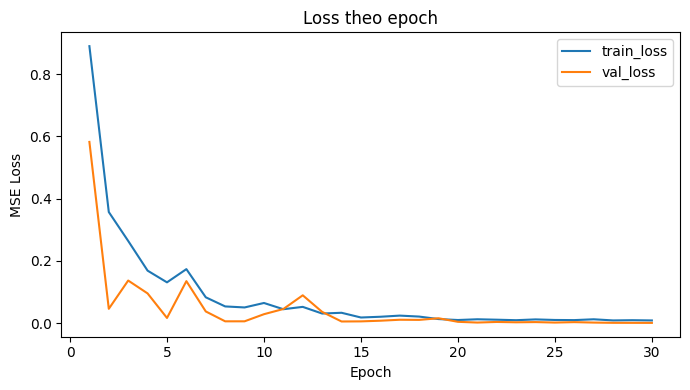

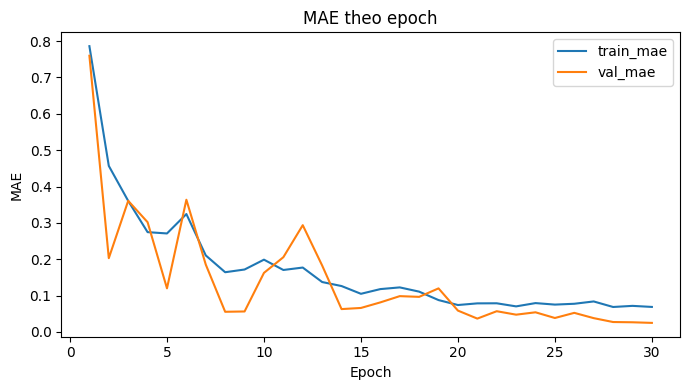

In [9]:
# Cell 8_plot — Plot training curves (Loss & MAE)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HIST_CSV = Path("./data_thuydien/train_history_seq2_oomsafe.csv")
assert HIST_CSV.exists(), f"Không tìm thấy {HIST_CSV}. Hãy chạy Cell 8’ trước."

hist = pd.read_csv(HIST_CSV)

# Loss
plt.figure(figsize=(7,4))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"],   label="val_loss")
plt.title("Loss theo epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# MAE
plt.figure(figsize=(7,4))
plt.plot(hist["epoch"], hist["train_mae"], label="train_mae")
plt.plot(hist["epoch"], hist["val_mae"],   label="val_mae")
plt.title("MAE theo epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Cell 9 — Evaluate & export (AMP inference + batch nhỏ)
import numpy as np
import pandas as pd
import torch
from pathlib import Path

model.eval()
preds = []
BS_INF = 512  # giảm nếu vẫn OOM
with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
    for i in range(0, len(Xseq_te_s), BS_INF):
        xb_seq = torch.tensor(Xseq_te_s[i:i+BS_INF], dtype=torch.float32, device=DEVICE)
        xb_w   = torch.tensor(Xw_te_s[i:i+BS_INF],   dtype=torch.float32, device=DEVICE)
        yhat   = model(xb_seq, xb_w).detach().cpu().numpy().ravel()
        preds.append(yhat)
yhat_s = np.concatenate(preds, axis=0)

# Inverse scale về đơn vị m
y_pred = y_scaler.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
y_true = y_te

# Metrics
mae  = float(np.mean(np.abs(y_true - y_pred)))
rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
print(f"TEST — MAE={mae:.4f} | RMSE={rmse:.4f} (m)")

# Lưu kết quả
times = sub.loc[t_idx[test_mask], 'thoi_diem'].reset_index(drop=True)
pred_df = pd.DataFrame({'thoi_diem': times, 'y_true': y_true, 'y_pred': y_pred})
pred_df['abs_err'] = np.abs(pred_df['y_true'] - pred_df['y_pred'])
pred_path = Path('./data_thuydien/predictions_cnn_lstm_seq2_oomsafe.csv')
toperr_path = Path('./data_thuydien/npredictions_top_abs_err_seq2_oomsafe.csv')
pred_df.to_csv(pred_path, index=False)
pred_df.sort_values('abs_err', ascending=False).head(100).to_csv(toperr_path, index=False)
print("Saved:", pred_path)
print("Saved:", toperr_path)
print(pred_df.head(5))


TEST — MAE=1.9169 | RMSE=3.6055 (m)
Saved: data_thuydien/predictions_cnn_lstm_seq2_oomsafe.csv
Saved: data_thuydien/npredictions_top_abs_err_seq2_oomsafe.csv
            thoi_diem      y_true    y_pred   abs_err
0 2025-01-13 19:00:00  115.169998  115.5000  0.330002
1 2025-01-13 20:00:00  115.169998  115.5000  0.330002
2 2025-01-13 21:00:00  115.180000  115.5625  0.382500
3 2025-01-13 22:00:00  115.180000  115.6250  0.445000
4 2025-01-13 23:00:00  115.180000  115.7500  0.570000


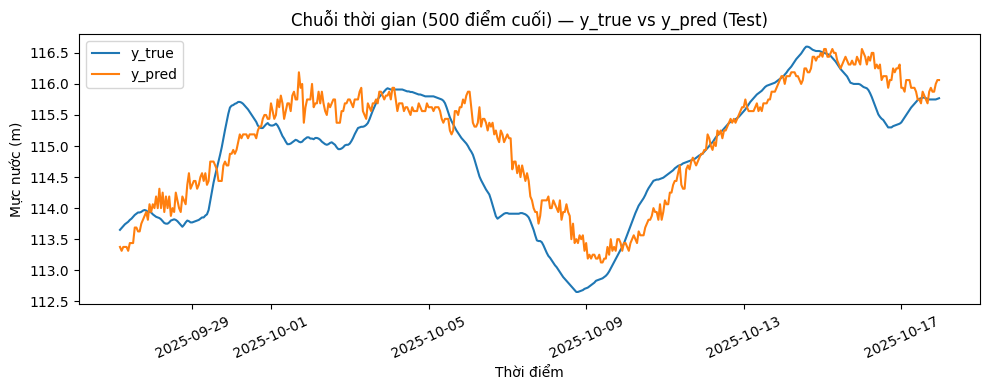

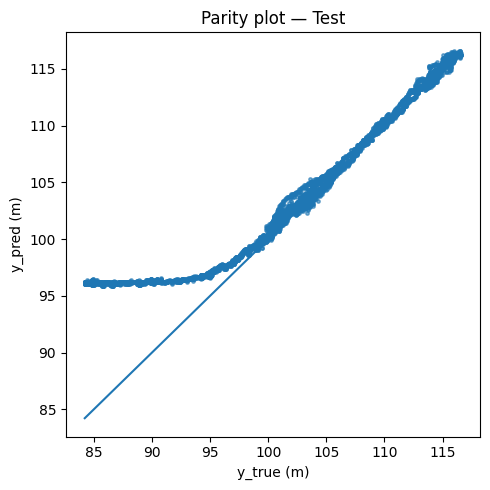

In [11]:
# Cell 9_plot — Plot test predictions (time-series + parity)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Giả định bạn vừa chạy Cell 9 và có pred_df, y_true, y_pred, times trong scope.
# Nếu không, đọc từ file CSV:
if 'pred_df' not in globals():
    _pred_path = "./data_thuydien/predictions_cnn_lstm_seq2_oomsafe.csv"
    pred_df = pd.read_csv(_pred_path, parse_dates=["thoi_diem"])

# 1) Time-series (lấy 500 điểm cuối cho dễ nhìn)
k = 500
slice_idx = slice(max(0, len(pred_df)-k), len(pred_df))
plt.figure(figsize=(10,4))
plt.plot(pred_df["thoi_diem"].values[slice_idx], pred_df["y_true"].values[slice_idx], label="y_true")
plt.plot(pred_df["thoi_diem"].values[slice_idx], pred_df["y_pred"].values[slice_idx], label="y_pred")
plt.title("Chuỗi thời gian (500 điểm cuối) — y_true vs y_pred (Test)")
plt.xlabel("Thời điểm")
plt.ylabel("Mực nước (m)")
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Parity plot: y_true vs y_pred
plt.figure(figsize=(5,5))
plt.scatter(pred_df["y_true"].values, pred_df["y_pred"].values, s=6, alpha=0.6)
mn = float(np.min([pred_df["y_true"].min(), pred_df["y_pred"].min()]))
mx = float(np.max([pred_df["y_true"].max(), pred_df["y_pred"].max()]))
plt.plot([mn, mx], [mn, mx])  # đường y=x
plt.title("Parity plot — Test")
plt.xlabel("y_true (m)")
plt.ylabel("y_pred (m)")
plt.tight_layout()
plt.show()
